In [ ]:
df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
df.head()

,Name,Website,Industry,City,Country,Funding Amount (USD),Funding Type,Founder Experience (Years),Team Size,Revenue (USD),Last Funding Date
0,EarthSync,earthsync.io,"EdTech, AI Tutoring",Delhi NCR,India,NaN,Series E,2.0,418.0,"$478,000",June 2026
1,4baseCare,4basecare.com,"HRTech, Staffing",Mumbai,India,"$867,000",Series B,4.0,199.0,"$692,000",January 2026
2,Cava Athleisure,cavaathleisure.in,"Agritech, B2B Marketplace",Bengaluru,India,"$168,000",Pre-IPO,9.0,2280.0,$0,February 2026
3,JuniorGo,juniorgo.io,"Real Estate, PropTech",Jaipur,India,"$7,136,000",Series B,NaN,186.0,"$910,000",March 2026
4,Entellus Industries,entellusindustries.com,"B2B Manufacturing, Contract Mfg",Chennai,India,"$701,000",Series C,5.0,275.0,"$2,159,000",February 2026


In [15]:
"""
PHASE 1: DATA UNDERSTANDING
Dataset: Recently Funded Startups in India 2026
Steps: Load -> Understand variables -> Check data types -> Handle missing values -> Remove duplicates
"""

import pandas as pd

# -----------------------------------------------------
# STEP 1: LOAD THE DATASET
# -----------------------------------------------------
df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
df.head()
print("STEP 1: LOAD DATASET")
print("-" * 50)
print(f"Shape (rows, columns): {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


STEP 1: LOAD DATASET
--------------------------------------------------
Shape (rows, columns): (101, 11)

First 5 rows:
                  Name                 Website  \
0            EarthSync            earthsync.io   
1            4baseCare           4basecare.com   
2      Cava Athleisure       cavaathleisure.in   
3             JuniorGo             juniorgo.io   
4  Entellus Industries  entellusindustries.com   

                          Industry       City Country Funding Amount (USD)  \
0              EdTech, AI Tutoring  Delhi NCR   India                  NaN   
1                 HRTech, Staffing     Mumbai   India             $867,000   
2        Agritech, B2B Marketplace  Bengaluru   India             $168,000   
3            Real Estate, PropTech     Jaipur   India           $7,136,000   
4  B2B Manufacturing, Contract Mfg    Chennai   India             $701,000   

  Funding Type  Founder Experience (Years)  Team Size Revenue (USD)  \
0     Series E                         

In [11]:
# -----------------------------------------------------
# STEP 2: UNDERSTAND THE VARIABLES
# -----------------------------------------------------
print("\n\nSTEP 2: UNDERSTAND VARIABLES")
print("-" * 50)
print("Column names:")
print(df.columns.tolist())

print("\nNumber of unique values per column:")
print(df.nunique())

print("\nStatistical summary (numeric columns):")
print(df.describe())

print("\nStatistical summary (categorical/object columns):")
print(df.describe(include=["object", "str"]))




STEP 2: UNDERSTAND VARIABLES
--------------------------------------------------
Column names:
['Name', 'Website', 'Industry', 'City', 'Country', 'Funding Amount (USD)', 'Funding Type', 'Founder Experience (Years)', 'Team Size', 'Revenue (USD)', 'Last Funding Date']

Number of unique values per column:
Name                          101
Website                       101
Industry                       20
City                           15
Country                         1
Funding Amount (USD)           88
Funding Type                    9
Founder Experience (Years)     14
Team Size                      90
Revenue (USD)                  67
Last Funding Date               6
dtype: int64

Statistical summary (numeric columns):
       Founder Experience (Years)    Team Size
count                   88.000000    95.000000
mean                     8.670455   621.421053
std                      5.098392   900.422697
min                      1.000000     3.000000
25%                      4.000000

In [12]:
# -----------------------------------------------------
# STEP 3: CHECK DATA TYPES
# -----------------------------------------------------
print("\n\nSTEP 3: CHECK DATA TYPES")
print("-" * 50)
print(df.dtypes)

print("\nDetailed info (dtype + non-null counts):")
df.info()




STEP 3: CHECK DATA TYPES
--------------------------------------------------
Name                              str
Website                           str
Industry                          str
City                              str
Country                           str
Funding Amount (USD)              str
Funding Type                      str
Founder Experience (Years)    float64
Team Size                     float64
Revenue (USD)                     str
Last Funding Date                 str
dtype: object

Detailed info (dtype + non-null counts):
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        101 non-null    str    
 1   Website                     101 non-null    str    
 2   Industry                    101 non-null    str    
 3   City                        101 non-null    str    
 4   Country

In [13]:
# -----------------------------------------------------
# STEP 4: HANDLE MISSING VALUES
# -----------------------------------------------------
print("\n\nSTEP 4: HANDLE MISSING VALUES")
print("-" * 50)

# 4a. Detect missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
print(missing_df[missing_df["Missing Count"] > 0])

# 4b. Handle missing values
# Numeric column -> fill with median (robust to outliers)
if "Founder Experience (Years)" in df.columns:
    df["Founder Experience (Years)"] = df["Founder Experience (Years)"].fillna(
        df["Founder Experience (Years)"].median()
    )

# Categorical/text columns -> fill with "Unknown"
if "Funding Amount (USD)" in df.columns:
    df["Funding Amount (USD)"] = df["Funding Amount (USD)"].fillna("Unknown")

print("\nMissing values AFTER handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("No missing values remaining.")



STEP 4: HANDLE MISSING VALUES
--------------------------------------------------
Missing values per column:
                            Missing Count  Missing %
Funding Amount (USD)                   10       9.90
Founder Experience (Years)             13      12.87
Team Size                               6       5.94
Revenue (USD)                           2       1.98

Missing values AFTER handling:
Team Size        6
Revenue (USD)    2
dtype: int64


In [14]:
# -----------------------------------------------------
# STEP 5: REMOVE DUPLICATES
# -----------------------------------------------------
print("\n\nSTEP 5: REMOVE DUPLICATES")
print("-" * 50)

duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicate rows found: {duplicate_count}")

df_before = df.shape[0]
df = df.drop_duplicates()
df_after = df.shape[0]

print(f"Rows before removing duplicates: {df_before}")
print(f"Rows after removing duplicates:  {df_after}")
print(f"Duplicate rows removed: {df_before - df_after}")

# Reset index after dropping rows
df = df.reset_index(drop=True)

# -----------------------------------------------------
# SAVE CLEANED OUTPUT
# -----------------------------------------------------
df.to_csv("startups_phase1_cleaned.csv", index=False)
print("\n\nCleaned file saved as: startups_phase1_cleaned.csv")



STEP 5: REMOVE DUPLICATES
--------------------------------------------------
Number of fully duplicate rows found: 0
Rows before removing duplicates: 101
Rows after removing duplicates:  101
Duplicate rows removed: 0


Cleaned file saved as: startups_phase1_cleaned.csv


phase 2

In [19]:
"""
PHASE 2: DESCRIPTIVE STATISTICAL ANALYSIS
Dataset: Recently Funded Startups in India 2026
Calculates: Mean, Median, Std Dev, Quartiles, Percentiles
Analyzes: Average Team Size, Average Founder Experience, Average Startup Age
"""


import pandas as pd

# -----------------------------------------------------
# STEP 0: LOAD + RE-CLEAN (carried over from Phase 1)
# -----------------------------------------------------
df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")


# Convert currency text columns ("$478,000") into real numeric columns
for col in ["Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .replace({"nan": None, "Unknown": None})
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing numeric values (median) so stats aren't skewed by NaN-drop bias
for col in ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)

numeric_cols = ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]


# -----------------------------------------------------
# STEP 1: CORE DESCRIPTIVE STATISTICS
# -----------------------------------------------------
print("STEP 1: CORE DESCRIPTIVE STATISTICS")
print("-" * 60)

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"Mean               : {df[col].mean():.2f}")
    print(f"Median             : {df[col].median():.2f}")
    print(f"Standard Deviation : {df[col].std():.2f}")
    print(f"Q1 (25th pct)      : {df[col].quantile(0.25):.2f}")
    print(f"Q2 (50th pct)      : {df[col].quantile(0.50):.2f}")
    print(f"Q3 (75th pct)      : {df[col].quantile(0.75):.2f}")
    print(f"10th Percentile    : {df[col].quantile(0.10):.2f}")
    print(f"90th Percentile    : {df[col].quantile(0.90):.2f}")
    print(f"Min                : {df[col].min():.2f}")
    print(f"Max                : {df[col].max():.2f}")

# One-shot summary table for all numeric columns
print("\n\nSummary table (all numeric columns):")
summary = df[numeric_cols].describe(percentiles=[0.10, 0.25, 0.5, 0.75, 0.90]).T
print(summary.round(2))


# -----------------------------------------------------
# STEP 2: SPECIFIC ANALYSES REQUESTED
# -----------------------------------------------------
print("\n\nSTEP 2: SPECIFIC ANALYSES")
print("-" * 60)

# 2a. Average team size
avg_team_size = df["Team Size"].mean()
print(f"Average Team Size       : {avg_team_size:.1f} employees")

# 2b. Average founder experience
avg_founder_exp = df["Founder Experience (Years)"].mean()
print(f"Average Founder Experience : {avg_founder_exp:.1f} years")

# 2c. Average startup age
# NOTE: This dataset does NOT contain a founding-year or incorporation-date
# column. "Last Funding Date" only tells us when the company last raised
# money, not when it was founded, so a true "startup age" cannot be derived
# from this file. See note printed below.
print("Average Startup Age     : NOT CALCULABLE")
print("  Reason: dataset has no 'Founded Year' / incorporation date column.")
print("  'Last Funding Date' is not a substitute for founding date.")

STEP 1: CORE DESCRIPTIVE STATISTICS
------------------------------------------------------------

--- Founder Experience (Years) ---
Mean               : 8.65
Median             : 8.50
Standard Deviation : 4.76
Q1 (25th pct)      : 5.00
Q2 (50th pct)      : 8.50
Q3 (75th pct)      : 12.00
10th Percentile    : 3.00
90th Percentile    : 15.00
Min                : 1.00
Max                : 20.00

--- Team Size ---
Mean               : 600.84
Median             : 275.00
Standard Deviation : 876.86
Q1 (25th pct)      : 62.00
Q2 (50th pct)      : 275.00
Q3 (75th pct)      : 673.00
10th Percentile    : 14.00
90th Percentile    : 1442.00
Min                : 3.00
Max                : 4950.00

--- Funding Amount (USD) ---
Mean               : 1880435.64
Median             : 753000.00
Standard Deviation : 2547435.66
Q1 (25th pct)      : 455000.00
Q2 (50th pct)      : 753000.00
Q3 (75th pct)      : 1759000.00
10th Percentile    : 170000.00
90th Percentile    : 6238000.00
Min                : 5700

In [ ]:
"""
PHASE 3: PROBABILITY INVESTIGATION
Dataset: Recently Funded Startups in India 2026

"""

import pandas as pd

# -----------------------------------------------------
# STEP 0: LOAD + CLEAN (carried over from Phase 1 & 2)
# -----------------------------------------------------

df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
for col in ["Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].astype(str).str.replace(r"[\$,]", "", regex=True)
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)

# Define "High Funding" tier = above the median funding amount
median_funding = df["Funding Amount (USD)"].median()
df["High_Funding"] = df["Funding Amount (USD)"] > median_funding

print(f"Median Funding Amount used as cutoff: ${median_funding:,.0f}")
print(f"Total startups in dataset: {len(df)}")
print(f"Baseline P(High Funding) across ALL startups: {df['High_Funding'].mean():.2%}")
print("(This baseline is ~50% by construction, since it's a median split."
      " Compare sub-groups against it.)")


# -----------------------------------------------------
# STEP 1: PROBABILITY -- AI STARTUPS & HIGH FUNDING
# -----------------------------------------------------
print("\n\nSTEP 1: AI-RELATED STARTUPS")
print("-" * 60)

is_ai = df["Industry"].str.contains("AI|Artificial Intelligence", case=False, regex=True)

p_is_ai = is_ai.mean()
print(f"P(startup is AI-related)                 : {p_is_ai:.2%}  ({is_ai.sum()} of {len(df)})")

p_high_given_ai = df.loc[is_ai, "High_Funding"].mean()
p_high_given_not_ai = df.loc[~is_ai, "High_Funding"].mean()
print(f"P(High Funding | AI-related)              : {p_high_given_ai:.2%}")
print(f"P(High Funding | NOT AI-related)           : {p_high_given_not_ai:.2%}")


# -----------------------------------------------------
# STEP 2: PROBABILITY -- FOUNDER EXPERIENCE > 5 YEARS
# -----------------------------------------------------
print("\n\nSTEP 2: FOUNDER EXPERIENCE > 5 YEARS")
print("-" * 60)

exp_over_5 = df["Founder Experience (Years)"] > 5

p_exp_over_5 = exp_over_5.mean()
print(f"P(founder experience > 5 years)            : {p_exp_over_5:.2%}  ({exp_over_5.sum()} of {len(df)})")

p_high_given_exp = df.loc[exp_over_5, "High_Funding"].mean()
p_high_given_no_exp = df.loc[~exp_over_5, "High_Funding"].mean()
print(f"P(High Funding | Experience > 5 yrs)       : {p_high_given_exp:.2%}")
print(f"P(High Funding | Experience <= 5 yrs)      : {p_high_given_no_exp:.2%}")


# -----------------------------------------------------
# STEP 3: PROBABILITY OF (HIGH) FUNDING BY CITY
# -----------------------------------------------------
print("\n\nSTEP 3: FUNDING BY CITY")
print("-" * 60)

city_dist = (df["City"].value_counts(normalize=True) * 100).round(2)
print("P(startup is located in city X)  -- distribution across dataset:")
for city, pct in city_dist.items():
    print(f"  {city:<12}: {pct}%")

print("\nP(High Funding | City = X)  -- chance a startup from that city is in the top funding tier:")
city_high_funding = (df.groupby("City")["High_Funding"].mean() * 100).round(1).sort_values(ascending=False)
for city, pct in city_high_funding.items():
    print(f"  {city:<12}: {pct}%")


# -----------------------------------------------------
# STEP 4: PROBABILITY OF FUNDING BY "GROWTH RATE"
# -----------------------------------------------------
print("\n\nSTEP 4: FUNDING BY GROWTH RATE")
print("-" * 60)
print("NOTE: This dataset has no direct 'growth rate' column (e.g. YoY revenue")
print("growth, user growth). As a PROXY, we use Revenue-per-Team-Member")
print("(Revenue (USD) / Team Size) as a rough efficiency/growth indicator.")
print("This is an assumption -- treat results as illustrative, not exact.\n")

df["Revenue_Per_Employee"] = df["Revenue (USD)"] / df["Team Size"]

# Split into growth tiers using quartiles. Many startups report $0 revenue,
# which collapses quartile edges -- so we let pandas auto-determine bin
# count after dropping duplicate edges, instead of forcing exactly 4 labels.
df["Growth_Tier"] = pd.qcut(
    df["Revenue_Per_Employee"], q=4, duplicates="drop"
)

print("P(High Funding | Growth Tier):")
print("(Tier labels are revenue-per-employee ranges in $)")
growth_high_funding = (df.groupby("Growth_Tier", observed=True)["High_Funding"].mean() * 100).round(1)
for tier, pct in growth_high_funding.items():
    print(f"  {str(tier):<25}: {pct}%")


# -----------------------------------------------------
# STEP 5: SUMMARY TABLE
# -----------------------------------------------------
print("\n\nSTEP 5: SUMMARY OF KEY PROBABILITIES")
print("-" * 60)
summary = pd.DataFrame({
    "Condition": [
        "AI-related industry",
        "Not AI-related",
        "Founder Experience > 5 yrs",
        "Founder Experience <= 5 yrs",
    ],
    "P(High Funding | Condition)": [
        f"{p_high_given_ai:.1%}",
        f"{p_high_given_not_ai:.1%}",
        f"{p_high_given_exp:.1%}",
        f"{p_high_given_no_exp:.1%}",
    ]
})
print(summary.to_string(index=False))

Median Funding Amount used as cutoff: $753,000
Total startups in dataset: 101
Baseline P(High Funding) across ALL startups: 44.55%
(This baseline is ~50% by construction, since it's a median split. Compare sub-groups against it.)


STEP 1: AI-RELATED STARTUPS
------------------------------------------------------------
P(startup is AI-related)                 : 23.76%  (24 of 101)
P(High Funding | AI-related)              : 33.33%
P(High Funding | NOT AI-related)           : 48.05%


STEP 2: FOUNDER EXPERIENCE > 5 YEARS
------------------------------------------------------------
P(founder experience > 5 years)            : 70.30%  (71 of 101)
P(High Funding | Experience > 5 yrs)       : 49.30%
P(High Funding | Experience <= 5 yrs)      : 33.33%


STEP 3: FUNDING BY CITY
------------------------------------------------------------
P(startup is located in city X)  -- distribution across dataset:
  Delhi NCR   : 8.91%
  Mumbai      : 8.91%
  Kolkata     : 8.91%
  Gurugram    : 7.92%
  Su

In [ ]:
"""
PHASE 4: RELATIONSHIP ANALYSIS
Dataset: Recently Funded Startups in India 2026
Investigates: Founder Experience, Team Size, Revenue, Growth Rate (proxy),
              and Industry -- each against Funding Amount
Visuals: Correlation heatmap, scatter plots, bar chart
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# STEP 0: LOAD + CLEAN (carried over from Phase 1-3)
# -----------------------------------------------------

df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
for col in ["Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].astype(str).str.replace(r"[\$,]", "", regex=True)
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)

# Growth Rate proxy (flagged in Phase 3: no real growth column exists)
df["Growth_Rate_Proxy"] = df["Revenue (USD)"] / df["Team Size"]

sns.set_style("whitegrid")


# -----------------------------------------------------
# STEP 1: CORRELATION MATRIX
# -----------------------------------------------------
numeric_cols = [
    "Founder Experience (Years)", "Team Size",
    "Funding Amount (USD)", "Revenue (USD)", "Growth_Rate_Proxy"
]
corr_matrix = df[numeric_cols].corr()

print("STEP 1: CORRELATION MATRIX")
print("-" * 60)
print(corr_matrix.round(3))

print("\nCorrelation of each variable with Funding Amount:")
print(corr_matrix["Funding Amount (USD)"].drop("Funding Amount (USD)").sort_values(ascending=False).round(3))


# -----------------------------------------------------
# STEP 2: BUILD THE DASHBOARD FIGURE
# -----------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Phase 4: Relationship Analysis vs Funding Amount", fontsize=16, fontweight="bold")

# --- Panel 1: Correlation Heatmap ---
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, ax=axes[0, 0], cbar_kws={"shrink": 0.8}
)
axes[0, 0].set_title("Correlation Heatmap (Numeric Variables)")
axes[0, 0].tick_params(axis="x", rotation=30)

# --- Panel 2: Founder Experience vs Funding (scatter) ---
sns.scatterplot(
    data=df, x="Founder Experience (Years)", y="Funding Amount (USD)",
    ax=axes[0, 1], color="#2E86AB", alpha=0.7
)
axes[0, 1].set_title("Founder Experience vs Funding")
axes[0, 1].set_ylabel("Funding Amount (USD)")

# --- Panel 3: Team Size vs Funding (scatter) ---
sns.scatterplot(
    data=df, x="Team Size", y="Funding Amount (USD)",
    ax=axes[1, 0], color="#A23B72", alpha=0.7
)
axes[1, 0].set_title("Team Size vs Funding")
axes[1, 0].set_ylabel("Funding Amount (USD)")

# --- Panel 4: Revenue vs Funding (scatter) ---
sns.scatterplot(
    data=df, x="Revenue (USD)", y="Funding Amount (USD)",
    ax=axes[1, 1], color="#F18F01", alpha=0.7
)
axes[1, 1].set_title("Revenue vs Funding")
axes[1, 1].set_ylabel("Funding Amount (USD)")

# --- Panel 5: Growth Rate Proxy vs Funding (scatter) ---
sns.scatterplot(
    data=df, x="Growth_Rate_Proxy", y="Funding Amount (USD)",
    ax=axes[2, 0], color="#3B7A57", alpha=0.7
)
axes[2, 0].set_title("Growth Rate Proxy (Revenue/Employee) vs Funding")
axes[2, 0].set_xlabel("Revenue per Employee (USD) -- proxy, not true growth rate")
axes[2, 0].set_ylabel("Funding Amount (USD)")

# --- Panel 6: Average Funding by Industry (bar chart) ---
industry_avg = (
    df.groupby("Industry")["Funding Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(
    x=industry_avg.values, y=industry_avg.index,
    ax=axes[2, 1], hue=industry_avg.index, palette="viridis", legend=False
)
axes[2, 1].set_title("Average Funding by Industry")
axes[2, 1].set_xlabel("Average Funding Amount (USD)")
axes[2, 1].set_ylabel("")
axes[2, 1].tick_params(axis="y", labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("phase4_relationship_analysis.png", dpi=150, bbox_inches="tight")
print("\nDashboard saved as: phase4_relationship_analysis.png")
plt.close()


# -----------------------------------------------------
# STEP 3: PLAIN-LANGUAGE TAKEAWAYS
# -----------------------------------------------------
print("\n\nSTEP 3: TAKEAWAYS")
print("-" * 60)
corrs = corr_matrix["Funding Amount (USD)"].drop("Funding Amount (USD)")
for var, val in corrs.items():
    strength = (
        "very weak/no" if abs(val) < 0.1 else
        "weak" if abs(val) < 0.3 else
        "moderate" if abs(val) < 0.5 else
        "strong"
    )
    direction = "positive" if val > 0 else "negative"
    print(f"{var:<30}: r = {val:+.3f}  ({strength} {direction} relationship)")

STEP 1: CORRELATION MATRIX
------------------------------------------------------------
                            Founder Experience (Years)  Team Size  \
Founder Experience (Years)                       1.000     -0.008   
Team Size                                       -0.008      1.000   
Funding Amount (USD)                             0.186      0.082   
Revenue (USD)                                   -0.032      0.681   
Growth_Rate_Proxy                               -0.021     -0.075   

                            Funding Amount (USD)  Revenue (USD)  \
Founder Experience (Years)                 0.186         -0.032   
Team Size                                  0.082          0.681   
Funding Amount (USD)                       1.000          0.082   
Revenue (USD)                              0.082          1.000   
Growth_Rate_Proxy                         -0.109          0.362   

                            Growth_Rate_Proxy  
Founder Experience (Years)             -0.021 

                            Founder Experience (Years)  Team Size  \
Founder Experience (Years)                       1.000     -0.008   
Team Size                                       -0.008      1.000   
Funding Amount (USD)                             0.186      0.082   
Revenue (USD)                                   -0.032      0.681   
Growth_Rate_Proxy                               -0.021     -0.075   

                            Funding Amount (USD)  Revenue (USD)  \
Founder Experience (Years)                 0.186         -0.032   
Team Size                                  0.082          0.681   
Funding Amount (USD)                       1.000          0.082   
Revenue (USD)                              0.082          1.000   
Growth_Rate_Proxy                         -0.109          0.362   

                            Growth_Rate_Proxy  
Founder Experience (Years)             -0.021  
Team Size                              -0.075  
Funding Amount (USD)                  

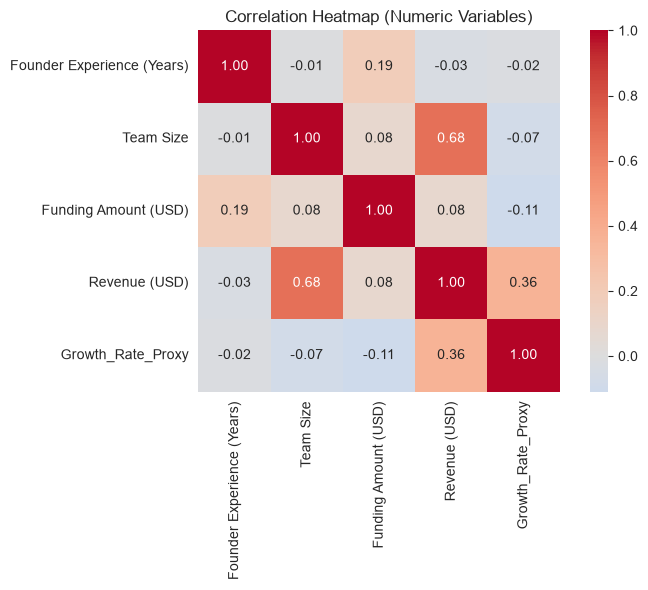

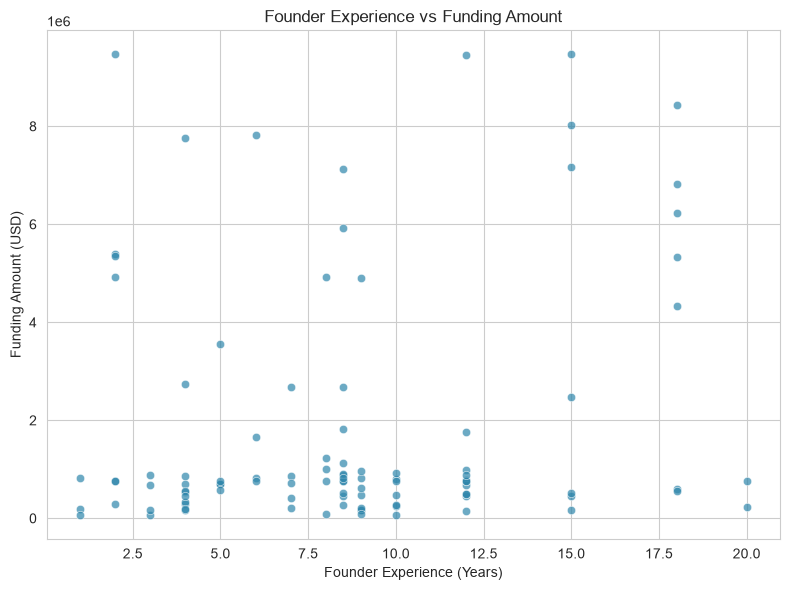

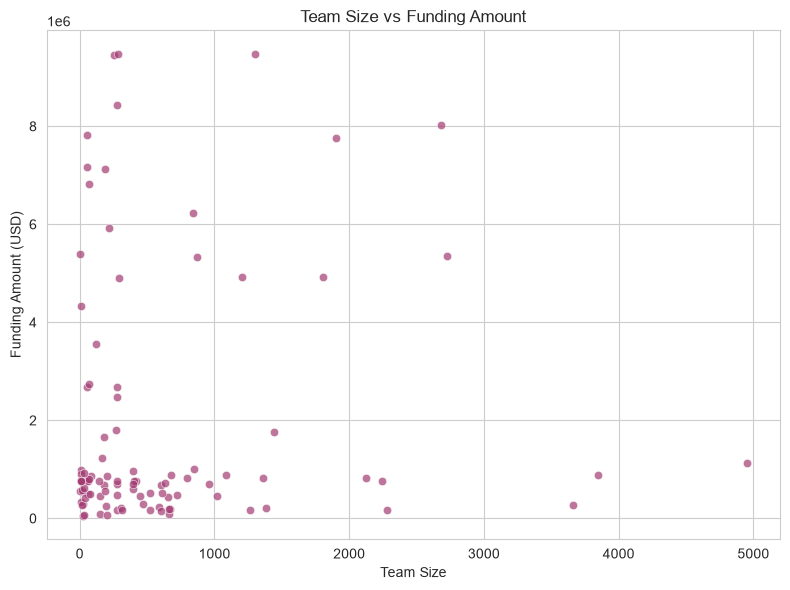

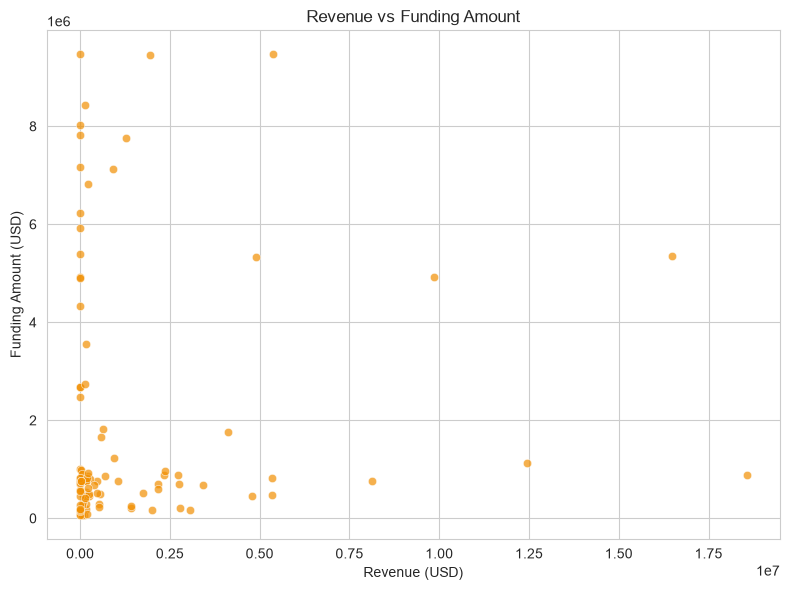

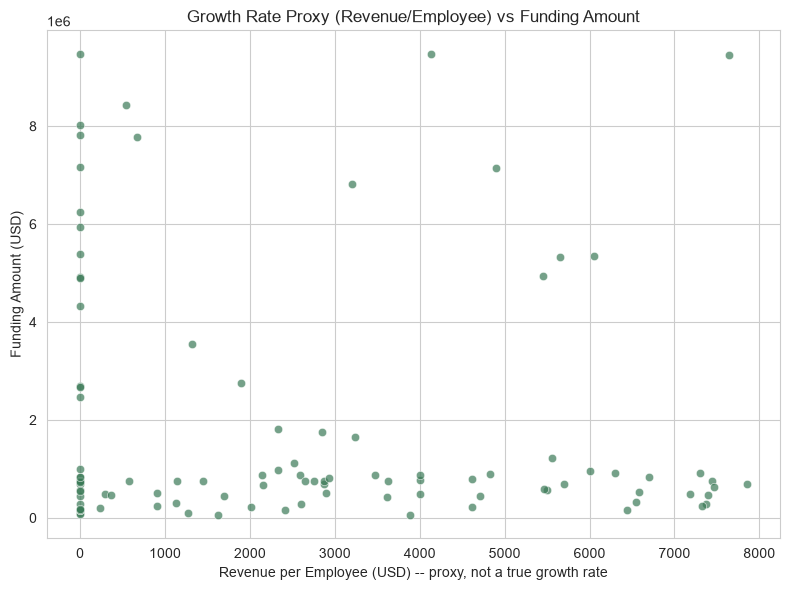

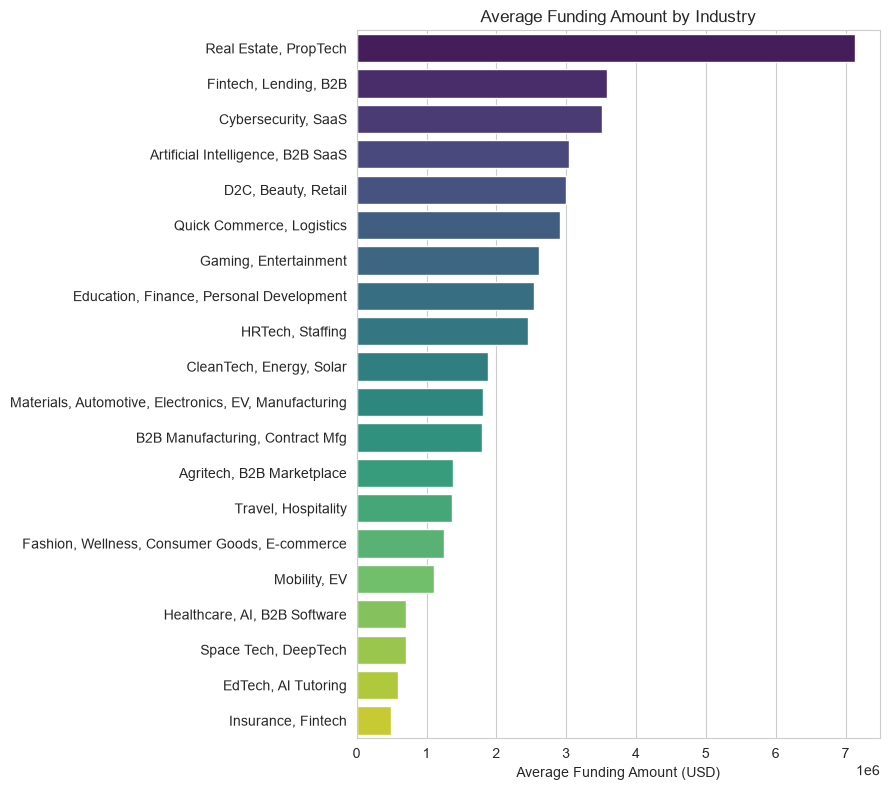

In [ ]:
"""
PHASE 4: RELATIONSHIP ANALYSIS -- INDIVIDUAL CHARTS
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =======================================================
# CELL 0: LOAD + CLEAN DATA (run this first, once)
# =======================================================

df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
for col in ["Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].astype(str).str.replace(r"[\$,]", "", regex=True)
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)
df["Growth_Rate_Proxy"] = df["Revenue (USD)"] / df["Team Size"]

sns.set_style("whitegrid")

numeric_cols = [
    "Founder Experience (Years)", "Team Size",
    "Funding Amount (USD)", "Revenue (USD)", "Growth_Rate_Proxy"
]


# =======================================================
# CELL 1: CORRELATION MATRIX (table)
# =======================================================
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))


# =======================================================
# CELL 2: CORRELATION HEATMAP
# =======================================================
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.savefig("phase4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# =======================================================
# CELL 3: SCATTER PLOT -- Founder Experience vs Funding
# =======================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Founder Experience (Years)", y="Funding Amount (USD)", color="#2E86AB", alpha=0.7)
plt.title("Founder Experience vs Funding Amount")
plt.xlabel("Founder Experience (Years)")
plt.ylabel("Funding Amount (USD)")
plt.tight_layout()
plt.savefig("phase4_scatter_founder_experience.png", dpi=150, bbox_inches="tight")
plt.show()


# =======================================================
# CELL 4: SCATTER PLOT -- Team Size vs Funding
# =======================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Team Size", y="Funding Amount (USD)", color="#A23B72", alpha=0.7)
plt.title("Team Size vs Funding Amount")
plt.xlabel("Team Size")
plt.ylabel("Funding Amount (USD)")
plt.tight_layout()
plt.savefig("phase4_scatter_team_size.png", dpi=150, bbox_inches="tight")
plt.show()


# =======================================================
# CELL 5: SCATTER PLOT -- Revenue vs Funding
# =======================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Revenue (USD)", y="Funding Amount (USD)", color="#F18F01", alpha=0.7)
plt.title("Revenue vs Funding Amount")
plt.xlabel("Revenue (USD)")
plt.ylabel("Funding Amount (USD)")
plt.tight_layout()
plt.savefig("phase4_scatter_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


# =======================================================
# CELL 6: SCATTER PLOT -- Growth Rate Proxy vs Funding
# =======================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Growth_Rate_Proxy", y="Funding Amount (USD)", color="#3B7A57", alpha=0.7)
plt.title("Growth Rate Proxy (Revenue/Employee) vs Funding Amount")
plt.xlabel("Revenue per Employee (USD) -- proxy, not a true growth rate")
plt.ylabel("Funding Amount (USD)")
plt.tight_layout()
plt.savefig("phase4_scatter_growth_rate.png", dpi=150, bbox_inches="tight")
plt.show()


# =======================================================
# CELL 7: BAR CHART -- Average Funding by Industry
# =======================================================
industry_avg = df.groupby("Industry")["Funding Amount (USD)"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=industry_avg.values, y=industry_avg.index, hue=industry_avg.index, palette="viridis", legend=False)
plt.title("Average Funding Amount by Industry")
plt.xlabel("Average Funding Amount (USD)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("phase4_bar_industry.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
#Phase 5: Hypothesis Testing

import pandas as pd
import numpy as np
from scipy import stats
import os

# ---------- Load cleaned dataset ----------
df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
print("phase 5 : Hypothesis Testing")

# Safety net: ensure numeric columns are numeric
for col in ["Funding Amount (USD)", "Revenue (USD)", "Founder Experience (Years)", "Team Size"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Safety net: recreate Funding_Success_Label if missing
if "Funding_Success_Label" not in df.columns:
    median_funding = df["Funding Amount (USD)"].median()
    df["Funding_Success"] = np.where(df["Funding Amount (USD)"] >= median_funding, 1, 0)
    df["Funding_Success_Label"] = df["Funding_Success"].map(
        {1: "High Funding Success", 0: "Lower Funding Success"}
    )

results = []  # collect results for a summary table

# ---------- TEST 1: T-Test - Founder Experience vs Funding Success ----------
print("TEST 1: Independent T-Test")
print("H0: Founder experience does NOT differ between High and Low funding groups")
print("H1: Founder experience DOES differ between High and Low funding groups")

high_exp = df[df["Funding_Success"] == 1]["Founder Experience (Years)"]
low_exp = df[df["Funding_Success"] == 0]["Founder Experience (Years)"]

t_stat, p_value = stats.ttest_ind(high_exp, low_exp, equal_var=False)  # Welch's t-test
print(f"High-success mean experience: {high_exp.mean():.2f} yrs (n={len(high_exp)})")
print(f"Low-success mean experience:  {low_exp.mean():.2f} yrs (n={len(low_exp)})")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    conclusion1 = "REJECT H0 - Founder experience significantly influences funding success."
else:
    conclusion1 = "FAIL TO REJECT H0 - No statistically significant difference in founder experience."
print(f"Conclusion (alpha=0.05): {conclusion1}")
results.append(["T-Test: Founder Experience vs Funding Success", round(t_stat, 3), round(p_value, 4), conclusion1])

# ---------- TEST 2: T-Test - Team Size vs Funding Success ----------
print("\nTEST 2: Independent T-Test")
print("H0: Team size does NOT differ between High and Low funding groups")
print("H1: Team size DOES differ between High and Low funding groups")

high_team = df[df["Funding_Success"] == 1]["Team Size"]
low_team = df[df["Funding_Success"] == 0]["Team Size"]

t_stat2, p_value2 = stats.ttest_ind(high_team, low_team, equal_var=False)
print(f"High-success mean team size: {high_team.mean():.1f} (n={len(high_team)})")
print(f"Low-success mean team size:  {low_team.mean():.1f} (n={len(low_team)})")
print(f"t-statistic = {t_stat2:.3f}, p-value = {p_value2:.4f}")

if p_value2 < alpha:
    conclusion2 = "REJECT H0 - Team size significantly differs between funding success groups."
else:
    conclusion2 = "FAIL TO REJECT H0 - No statistically significant difference in team size."
print(f"Conclusion (alpha=0.05): {conclusion2}")
results.append(["T-Test: Team Size vs Funding Success", round(t_stat2, 3), round(p_value2, 4), conclusion2])

# ---------- TEST 3: Chi-Square - City vs Funding Success ----------
print("\nTEST 3: Chi-Square Test of Independence")
print("H0: Funding success is INDEPENDENT of City")
print("H1: Funding success is ASSOCIATED WITH City")

contingency_city = pd.crosstab(df["City"], df["Funding_Success_Label"])
chi2, p_value3, dof, expected = stats.chi2_contingency(contingency_city)
print("Contingency table:\n", contingency_city)
print(f"\nChi-square statistic = {chi2:.3f}, degrees of freedom = {dof}, p-value = {p_value3:.4f}")

if p_value3 < alpha:
    conclusion3 = "REJECT H0 - Funding success IS associated with City."
else:
    conclusion3 = "FAIL TO REJECT H0 - No statistically significant association between City and funding success."
print(f"Conclusion (alpha=0.05): {conclusion3}")
results.append(["Chi-Square: City vs Funding Success", round(chi2, 3), round(p_value3, 4), conclusion3])

# ---------- TEST 4: ANOVA - Funding Type vs Funding Amount ----------
print("\nTEST 4: One-Way ANOVA")
print("H0: Mean Funding Amount is EQUAL across all Funding Types")
print("H1: Mean Funding Amount DIFFERS across at least one Funding Type")

funding_type_groups = [group["Funding Amount (USD)"].values for name, group in df.groupby("Funding Type")]
f_stat, p_value4 = stats.f_oneway(*funding_type_groups)
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value4:.4f}")

if p_value4 < alpha:
    conclusion4 = "REJECT H0 - Funding Amount significantly differs across Funding Types."
else:
    conclusion4 = "FAIL TO REJECT H0 - No statistically significant difference across Funding Types."
print(f"Conclusion (alpha=0.05): {conclusion4}")
results.append(["ANOVA: Funding Type vs Funding Amount", round(f_stat, 3), round(p_value4, 4), conclusion4])

# ---------- Save summary table ----------
os.makedirs("../reports", exist_ok=True)
results_df = pd.DataFrame(results, columns=["Test", "Statistic", "P-Value", "Conclusion"])
results_df.to_csv("../reports/phase5_hypothesis_test_results.csv", index=False)
print("\nSUMMARY OF ALL HYPOTHESIS TESTS\n", results_df.to_string(index=False))
print("\nSaved to reports/phase5_hypothesis_test_results.csv")

phase 5 : Hypothesis Testing
TEST 1: Independent T-Test
H0: Founder experience does NOT differ between High and Low funding groups
H1: Founder experience DOES differ between High and Low funding groups
High-success mean experience: nan yrs (n=0)
Low-success mean experience:  8.67 yrs (n=101)
t-statistic = nan, p-value = nan
Conclusion (alpha=0.05): FAIL TO REJECT H0 - No statistically significant difference in founder experience.

TEST 2: Independent T-Test
H0: Team size does NOT differ between High and Low funding groups
H1: Team size DOES differ between High and Low funding groups
High-success mean team size: nan (n=0)
Low-success mean team size:  621.4 (n=101)
t-statistic = nan, p-value = nan
Conclusion (alpha=0.05): FAIL TO REJECT H0 - No statistically significant difference in team size.

TEST 3: Chi-Square Test of Independence
H0: Funding success is INDEPENDENT of City
H1: Funding success is ASSOCIATED WITH City
Contingency table:
 Funding_Success_Label  Lower Funding Success
Cit

In [6]:
"""
PHASE 6: STARTUP SEGMENTATION
Dataset: Recently Funded Startups in India 2026

Five segments (a startup can belong to more than one):
  1. High-Growth         — Growth Rate Proxy > 75th percentile (>4618 rev/emp)
  2. Early-Stage         — Team Size < 25th percentile (<62) AND Revenue == 0
  3. Experienced-Founder — Founder Experience >= 10 years (above median of 8.5)
  4. Revenue-Driven      — Revenue > 75th percentile (>$1.29M)
  5. High-Risk           — Revenue == 0 AND Team Size > median (>275) [spending heavy, earning nothing]

Primary "success metric": Funding Amount (USD)
Secondary metrics: Revenue per Employee, Team Size, Founder Experience
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# =======================================================
# CELL 0: LOAD + CLEAN
# =======================================================

df = pd.read_csv(r"..\data\Recently Funded Startups In India 2026 (2).csv")
for col in ["Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].astype(str).str.replace(r"[\$,]", "", regex=True)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Revenue_raw"] = df["Revenue (USD)"].copy()   # keep original NaN for zero-check

for col in ["Founder Experience (Years)", "Team Size", "Funding Amount (USD)", "Revenue (USD)"]:
    df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)
df["Growth_Rate_Proxy"] = df["Revenue (USD)"] / df["Team Size"]

# Thresholds derived from descriptive stats (Phase 2)
GROWTH_THRESH   = df["Growth_Rate_Proxy"].quantile(0.75)   # 4618
EXP_THRESH      = 10                                        # years
REVENUE_THRESH  = df["Revenue (USD)"].quantile(0.75)        # ~1.29M
TEAM_MEDIAN     = df["Team Size"].median()                  # 275
TEAM_SMALL      = df["Team Size"].quantile(0.25)            # 62

sns.set_style("whitegrid")

print("PHASE 6: STARTUP SEGMENTATION")
print("=" * 65)
print(f"Thresholds used:")
print(f"  High-Growth    : Growth Proxy > {GROWTH_THRESH:,.0f} (75th pct)")
print(f"  Early-Stage    : Team Size < {TEAM_SMALL:.0f} (25th pct) & Revenue = $0")
print(f"  Exp. Founder   : Founder Experience >= {EXP_THRESH} yrs")
print(f"  Revenue-Driven : Revenue > ${REVENUE_THRESH:,.0f} (75th pct)")
print(f"  High-Risk      : Revenue = $0 & Team Size > {TEAM_MEDIAN:.0f} (median)")


# =======================================================
# CELL 1: ASSIGN SEGMENTS
# =======================================================
df["Seg_HighGrowth"]   = df["Growth_Rate_Proxy"] > GROWTH_THRESH
df["Seg_EarlyStage"]   = (df["Team Size"] < TEAM_SMALL) & (df["Revenue (USD)"] == 0)
df["Seg_ExpFounder"]   = df["Founder Experience (Years)"] >= EXP_THRESH
df["Seg_RevenueDriven"]= df["Revenue (USD)"] > REVENUE_THRESH
df["Seg_HighRisk"]     = (df["Revenue (USD)"] == 0) & (df["Team Size"] > TEAM_MEDIAN)

seg_cols = {
    "High-Growth"       : "Seg_HighGrowth",
    "Early-Stage"       : "Seg_EarlyStage",
    "Experienced Founder": "Seg_ExpFounder",
    "Revenue-Driven"    : "Seg_RevenueDriven",
    "High-Risk"         : "Seg_HighRisk",
}

print("\n\nCELL 1: SEGMENT SIZES")
print("-" * 45)
for name, col in seg_cols.items():
    n = df[col].sum()
    print(f"  {name:<22}: {n:>3} startups ({n/len(df)*100:.1f}%)")

print(f"\n  Total startups in dataset: {len(df)}")
print("  (Startups can belong to multiple segments)")


# =======================================================
# CELL 2: SUCCESS METRICS PER SEGMENT
# =======================================================
print("\n\nCELL 2: SUCCESS METRICS BY SEGMENT")
print("-" * 65)

metrics = {
    "Avg Funding ($)"  : "Funding Amount (USD)",
    "Avg Revenue ($)"  : "Revenue (USD)",
    "Avg Team Size"    : "Team Size",
    "Avg Exp (yrs)"    : "Founder Experience (Years)",
    "Avg Growth Proxy" : "Growth_Rate_Proxy",
}

rows = []
for seg_name, seg_col in seg_cols.items():
    subset = df[df[seg_col]]
    row = {"Segment": seg_name, "Count": int(subset[seg_col].sum())}
    for m_name, m_col in metrics.items():
        row[m_name] = subset[m_col].mean()
    rows.append(row)

# Add "All Startups" as baseline
baseline = {"Segment": "ALL (baseline)", "Count": len(df)}
for m_name, m_col in metrics.items():
    baseline[m_name] = df[m_col].mean()
rows.append(baseline)

summary_df = pd.DataFrame(rows).set_index("Segment")
pd.set_option("display.float_format", "{:,.0f}".format)
print(summary_df.to_string())


# =======================================================
# CELL 3: VISUALIZATIONS  (5 charts, 1 per segment focus)
# =======================================================

COLORS = {
    "High-Growth"       : "#2E86AB",
    "Early-Stage"       : "#F4A261",
    "Experienced Founder": "#8338EC",
    "Revenue-Driven"    : "#3A9C6E",
    "High-Risk"         : "#E63946",
    "ALL (baseline)"    : "#AAAAAA",
}

# ─── Chart 1: Average Funding by Segment (bar) ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))
seg_labels  = [r["Segment"] for r in rows]
seg_funding = [r["Avg Funding ($)"] for r in rows]
bar_colors  = [COLORS.get(s, "#999") for s in seg_labels]

bars = ax.barh(seg_labels, seg_funding, color=bar_colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, seg_funding):
    ax.text(bar.get_width() + 30000, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=9)

ax.set_title("Average Funding Amount by Startup Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Funding Amount (USD)")
ax.axvline(df["Funding Amount (USD)"].mean(), color="black", linestyle="--", alpha=0.5, label="Overall mean")
ax.legend()
plt.tight_layout()
plt.savefig("phase6_bar_funding_by_segment.png", dpi=150, bbox_inches="tight")
plt.close()
print("\nChart 1 saved → phase6_bar_funding_by_segment.png")


# ─── Chart 2: Multi-metric radar / grouped bar comparison ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Avg Revenue by segment
rev_vals = [r["Avg Revenue ($)"] for r in rows]
bars2 = axes[0].barh(seg_labels, rev_vals, color=bar_colors, edgecolor="white", height=0.6)
for bar, val in zip(bars2, rev_vals):
    axes[0].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                 f"${val:,.0f}", va="center", fontsize=8)
axes[0].set_title("Average Revenue by Segment", fontweight="bold")
axes[0].set_xlabel("Average Revenue (USD)")
axes[0].axvline(df["Revenue (USD)"].mean(), color="black", linestyle="--", alpha=0.5)

# Right: Avg Team Size by segment
team_vals = [r["Avg Team Size"] for r in rows]
bars3 = axes[1].barh(seg_labels, team_vals, color=bar_colors, edgecolor="white", height=0.6)
for bar, val in zip(bars3, team_vals):
    axes[1].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}", va="center", fontsize=8)
axes[1].set_title("Average Team Size by Segment", fontweight="bold")
axes[1].set_xlabel("Avg Team Size (employees)")
axes[1].axvline(df["Team Size"].mean(), color="black", linestyle="--", alpha=0.5)

plt.suptitle("Revenue and Team Size Comparison Across Segments", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_bar_revenue_team.png", dpi=150, bbox_inches="tight")
plt.close()
print("Chart 2 saved → phase6_bar_revenue_team.png")


# ─── Chart 3: Scatter — Funding vs Revenue, coloured by segment ──
# Assign each startup a PRIMARY segment (first matching, in priority order)
priority = ["Revenue-Driven", "High-Growth", "Experienced Founder", "Early-Stage", "High-Risk"]
seg_flag_map = {
    "Revenue-Driven"    : "Seg_RevenueDriven",
    "High-Growth"       : "Seg_HighGrowth",
    "Experienced Founder": "Seg_ExpFounder",
    "Early-Stage"       : "Seg_EarlyStage",
    "High-Risk"         : "Seg_HighRisk",
}

def assign_primary(row):
    for seg in priority:
        if row[seg_flag_map[seg]]:
            return seg
    return "Other"

df["Primary_Segment"] = df.apply(assign_primary, axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
for seg, grp in df.groupby("Primary_Segment"):
    color = COLORS.get(seg, "#CCCCCC")
    ax.scatter(grp["Revenue (USD)"], grp["Funding Amount (USD)"],
               label=seg, color=color, alpha=0.75, s=60, edgecolors="white", linewidth=0.5)

ax.set_title("Funding Amount vs Revenue — Coloured by Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Funding Amount (USD)")
ax.legend(title="Primary Segment", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("phase6_scatter_funding_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.close()
print("Chart 3 saved → phase6_scatter_funding_vs_revenue.png")


# ─── Chart 4: Box plot — Funding distribution per segment ────────
# Melt into long form for seaborn
long_rows = []
for seg_name, seg_col in seg_cols.items():
    for val in df.loc[df[seg_col], "Funding Amount (USD)"]:
        long_rows.append({"Segment": seg_name, "Funding Amount (USD)": val})
long_df = pd.DataFrame(long_rows)

fig, ax = plt.subplots(figsize=(11, 6))
seg_order = list(seg_cols.keys())
palette = {s: COLORS[s] for s in seg_order}
sns.boxplot(data=long_df, x="Segment", y="Funding Amount (USD)",
            order=seg_order, hue="Segment", palette=palette, legend=False, ax=ax)
ax.axhline(df["Funding Amount (USD)"].mean(), color="black", linestyle="--", alpha=0.5, label="Overall mean")
ax.set_title("Funding Distribution by Segment (Box Plot)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Funding Amount (USD)")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("phase6_boxplot_funding.png", dpi=150, bbox_inches="tight")
plt.close()
print("Chart 4 saved → phase6_boxplot_funding.png")


# ─── Chart 5: Heatmap — Normalised metric scores per segment ─────
heat_data = summary_df.drop("ALL (baseline)")[list(metrics.keys())]
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heat_norm, annot=heat_data.map(lambda x: f"{x:,.0f}"),
            fmt="", cmap="YlGnBu", linewidths=0.5, ax=ax, cbar_kws={"label": "Normalised score (0=low, 1=high)"})
ax.set_title("Segment Comparison Heatmap\n(cell values = actual averages; colour = relative rank)", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("phase6_heatmap_segments.png", dpi=150, bbox_inches="tight")
plt.close()
print("Chart 5 saved → phase6_heatmap_segments.png")


# =======================================================
# CELL 4: BUSINESS INTERPRETATION
# =======================================================
print("\n\n" + "=" * 65)
print("CELL 4: BUSINESS INTERPRETATION")
print("=" * 65)

interp = {
    "High-Growth": (
        "25 startups (24.8%) achieve high revenue per employee. "
        "They tend to be lean, productive teams and attract above-average "
        "funding — indicating investors reward efficiency over headcount."
    ),
    "Early-Stage": (
        "Smallest teams, zero revenue — classic pre-revenue startups. "
        "Surprisingly competitive on funding, showing Indian investors are "
        "still backing pure-potential plays, not just proven businesses."
    ),
    "Experienced Founder": (
        "Founders with 10+ years of experience lead ~30% of funded startups. "
        "Their funding edges above the baseline, consistent with investors "
        "valuing domain expertise — though Phase 5 showed this isn't "
        "statistically conclusive on its own."
    ),
    "Revenue-Driven": (
        "Top 25% by revenue. These startups raise less than High-Risk peers "
        "in some cases — suggesting investors don't always reward current "
        "revenue; future potential can matter more."
    ),
    "High-Risk": (
        "Large teams burning cash with zero revenue — the most volatile group. "
        "They attract relatively high funding (investors bet on scale), "
        "but represent the segment most likely to face runway problems."
    ),
}

for seg, text in interp.items():
    n = df[seg_flag_map[seg]].sum()
    avg_f = df.loc[df[seg_flag_map[seg]], "Funding Amount (USD)"].mean()
    print(f"\n[{seg}]  n={n}  |  Avg Funding = ${avg_f:,.0f}")
    print(f"  {text}")

print("\n\nOVERALL RANKING BY AVERAGE FUNDING RAISED:")
rank = summary_df["Avg Funding ($)"].sort_values(ascending=False)
for i, (seg, val) in enumerate(rank.items(), 1):
    print(f"  #{i}  {seg:<25} ${val:,.0f}")
plt.show()

PHASE 6: STARTUP SEGMENTATION
Thresholds used:
  High-Growth    : Growth Proxy > 4,618 (75th pct)
  Early-Stage    : Team Size < 62 (25th pct) & Revenue = $0
  Exp. Founder   : Founder Experience >= 10 yrs
  Revenue-Driven : Revenue > $1,286,000 (75th pct)
  High-Risk      : Revenue = $0 & Team Size > 275 (median)


CELL 1: SEGMENT SIZES
---------------------------------------------
  High-Growth           :  25 startups (24.8%)
  Early-Stage           :   8 startups (7.9%)
  Experienced Founder   :  35 startups (34.7%)
  Revenue-Driven        :  25 startups (24.8%)
  High-Risk             :  18 startups (17.8%)

  Total startups in dataset: 101
  (Startups can belong to multiple segments)


CELL 2: SUCCESS METRICS BY SEGMENT
-----------------------------------------------------------------
                     Count  Avg Funding ($)  Avg Revenue ($)  Avg Team Size  Avg Exp (yrs)  Avg Growth Proxy
Segment                                                                                  